In [ ]:
! pip install -q librosa soundfile matplotlib 
! pip install torch==2.5.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
# ! pip install --no-deps unsloth unsloth_zoo
! pip install librosa soundfile evaluate jiwer
! pip install "datasets>=3.4.1,<4.0.0"

In [ ]:
! python -m pip install torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu121
! python -c "import torch, torchvision; print(torch.__version__, torchvision.__version__, torch.cuda.is_available())"

In [ ]:
! python -m pip install "transformers==4.56.2"
! python -c "import torch; print(torch.__version__, torch.cuda.is_available())"

In [ ]:
! python -m pip uninstall -y unsloth unsloth_zoo
! python -m pip install -U peft accelerate bitsandbytes
! python -c "import torch, transformers, peft; print(torch.__version__, transformers.__version__, peft.__version__, torch.cuda.is_available())"

In [ ]:
! python -m pip uninstall -y torchao 

In [1]:
import json, numpy as np, librosa
from pathlib import Path
from transformers import WhisperFeatureExtractor

MODEL   = "unsloth/whisper-large-v3-turbo"
AUDIO_D = Path("/home/azureuser/cloudfiles/code/Users/kuladeep.a/STT_finetuning/stt_audio/audio")
TRANS_D = Path("/home/azureuser/cloudfiles/code/Users/kuladeep.a/STT_finetuning/stt_audio/transcribe_raw")

VID = "yt_UaE0D4CRCdk"          # change me

fe = WhisperFeatureExtractor.from_pretrained(MODEL)
print("sampling_rate   :", fe.sampling_rate)
print("n_fft           :", fe.n_fft, " ({} ms window)".format(1000*fe.n_fft//fe.sampling_rate))
print("hop_length      :", fe.hop_length, " ({} ms hop)".format(1000*fe.hop_length//fe.sampling_rate))
print("chunk_length    :", fe.chunk_length, "s")
print("n_samples       :", fe.n_samples)
print("feature_size    :", fe.feature_size, "  <-- MEL BINS (128 for v3/turbo, 80 for v2)")
print("expected frames :", fe.n_samples // fe.hop_length)

audio, sr = librosa.load(str(next(AUDIO_D.glob(VID + ".*"))), sr=fe.sampling_rate)
doc = json.loads((TRANS_D / (VID + ".json")).read_text())
print("\naudio: {:.1f} s   segments: {}".format(len(audio)/sr, len(doc["segments"])))

sampling_rate   : 16000
n_fft           : 400  (25 ms window)
hop_length      : 160  (10 ms hop)
chunk_length    : 30 s
n_samples       : 480000
feature_size    : 128   <-- MEL BINS (128 for v3/turbo, 80 for v2)
expected frames : 3000

audio: 1749.6 s   segments: 483


mel shape: (128, 3000)  dtype: float32
value range: -0.61 .. 1.39
words in window: 51


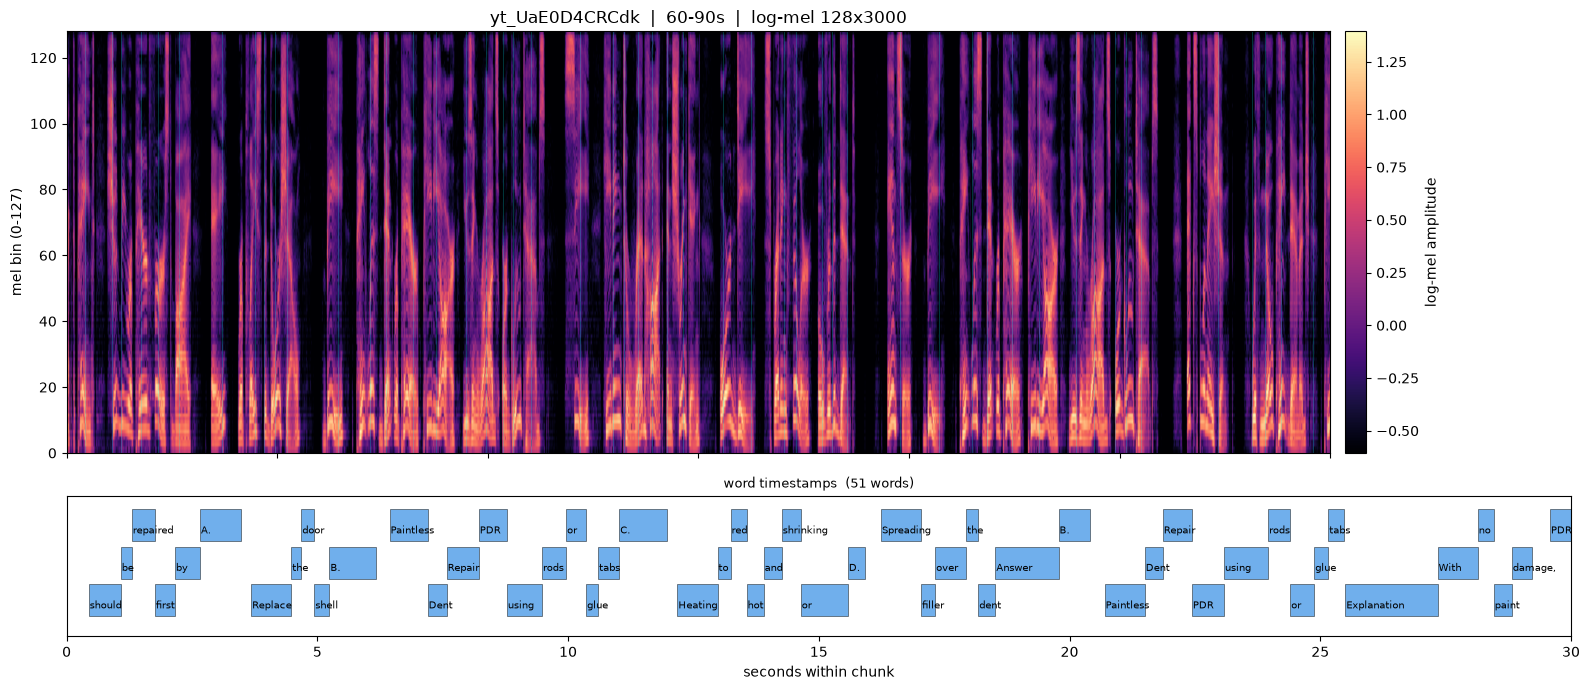


1 mel frame = 10 ms   |   100 frames/s   |   3000 frames = 30s


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

START = 60.0                     # chunk start in seconds
CHUNK = fe.chunk_length          # always 30

seg = audio[int(START*sr): int((START+CHUNK)*sr)]

# exactly what Whisper does internally: pad/trim to 30s, then log-mel
feats = fe(seg, sampling_rate=sr, return_tensors="np")
mel = feats.input_features[0]                     # (n_mels, 3000)
print("mel shape:", mel.shape, " dtype:", mel.dtype)
print("value range: {:.2f} .. {:.2f}".format(mel.min(), mel.max()))

# words falling inside this window
words = []
for s in doc["segments"]:
    for w in (s.get("words") or []):
        if START <= w["s"] < START + CHUNK:
            words.append(w)
print("words in window:", len(words))

frames_per_s = sr / fe.hop_length                 # 100 frames per second
fig, ax = plt.subplots(2, 1, figsize=(16, 7),
                       gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

im = ax[0].imshow(mel, aspect="auto", origin="lower", cmap="magma",
                  extent=[0, CHUNK, 0, mel.shape[0]])
ax[0].set_ylabel("mel bin (0-{})".format(mel.shape[0]-1))
ax[0].set_title("{}  |  {:.0f}-{:.0f}s  |  log-mel {}x{}".format(
    VID, START, START+CHUNK, mel.shape[0], mel.shape[1]))
fig.colorbar(im, ax=ax[0], pad=0.01, label="log-mel amplitude")

# word boxes on a ribbon under the spectrogram
for i, w in enumerate(words):
    x0, x1 = w["s"]-START, max(w["e"]-START, w["s"]-START+0.02)
    y = 0.15 + 0.28*(i % 3)                       # stagger so labels don't collide
    ax[0].axvline(x0, color="cyan", alpha=0.25, lw=0.6)
    ax[1].add_patch(mpatches.Rectangle((x0, y), x1-x0, 0.24,
                    facecolor="#4c9be8", edgecolor="k", lw=0.4, alpha=0.8))
    ax[1].text(x0+0.02, y+0.06, w["w"].strip(), fontsize=7, clip_on=True)

ax[1].set_xlim(0, CHUNK); ax[1].set_ylim(0, 1.05)
ax[1].set_yticks([]); ax[1].set_xlabel("seconds within chunk")
ax[1].set_title("word timestamps  ({} words)".format(len(words)), fontsize=9)
plt.tight_layout(); plt.show()

print("\n1 mel frame = {:.0f} ms   |   {:.0f} frames/s   |   {} frames = {}s".format(
    1000/frames_per_s, frames_per_s, mel.shape[1], CHUNK))

62 chunks | mean 27.8s | min 18.6 | max 30.0 | oversize 0
total audio used: 28.7 min

[   0.00 -   25.40]  25.4s  3 seg  This video is not affiliated with, endorsed by, or sponsored by the National I
[  25.40 -   54.94]  29.5s  6 seg  Hey everyone, welcome back to the channel. Today we've got something really he
[  55.50 -   85.48]  30.0s  7 seg  A minor door ding on a mild steel panel with intact paint should be repaired f
[  85.50 -  112.87]  27.4s  7 seg  Explanation With no paint damage, PDR preserves the OEM finish and avoids unne
[ 112.87 -  141.59]  28.7s  7 seg  C. Apply polyester primer A. Adhesion promoter for TPO after cleaning and scuf


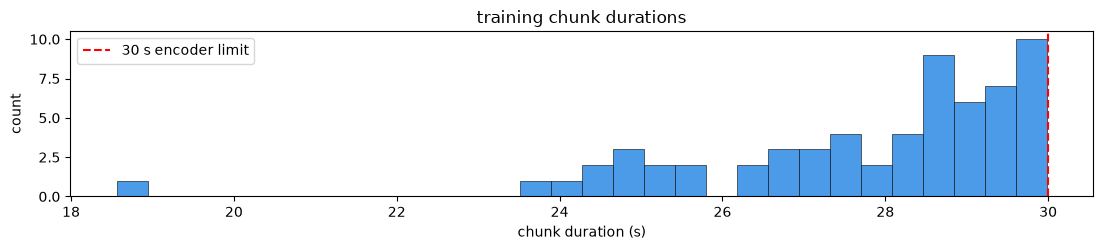

In [3]:
def make_chunks(segments, max_s=30.0, min_s=2.0):
    """Greedily pack consecutive segments into <=30s windows.
       Never splits a segment: the text must match the audio exactly."""
    chunks, cur = [], []
    for s in segments:
        if not (s.get("text") or "").strip():
            continue
        if s["end"] - s["start"] > max_s:          # single segment too long
            if cur: chunks.append(cur); cur = []
            chunks.append([s])                     # flag it, handle separately
            continue
        if cur and (s["end"] - cur[0]["start"]) > max_s:
            chunks.append(cur); cur = []
        cur.append(s)
    if cur: chunks.append(cur)

    out = []
    for c in chunks:
        st, en = c[0]["start"], c[-1]["end"]
        if en - st < min_s:
            continue
        out.append({"start": round(st, 2), "end": round(en, 2),
                    "dur": round(en - st, 2),
                    "text": " ".join(s["text"].strip() for s in c),
                    "n_segments": len(c),
                    "oversize": (en - st) > max_s})
    return out

chunks = make_chunks(doc["segments"])
over = [c for c in chunks if c["oversize"]]
durs = [c["dur"] for c in chunks]

print("{} chunks | mean {:.1f}s | min {:.1f} | max {:.1f} | oversize {}".format(
    len(chunks), np.mean(durs), min(durs), max(durs), len(over)))
print("total audio used: {:.1f} min\n".format(sum(durs)/60))

for c in chunks[:5]:
    print("[{:>7.2f} - {:>7.2f}] {:>5.1f}s  {} seg  {}".format(
        c["start"], c["end"], c["dur"], c["n_segments"], c["text"][:78]))

plt.figure(figsize=(11, 2.6))
plt.hist(durs, bins=30, color="#4c9be8", edgecolor="k", lw=0.4)
plt.axvline(30, color="r", ls="--", label="30 s encoder limit")
plt.xlabel("chunk duration (s)"); plt.ylabel("count"); plt.legend()
plt.title("training chunk durations"); plt.tight_layout(); plt.show()

In [4]:
import json, re, random
from pathlib import Path
import numpy as np
import torch

try:
    from tabulate import tabulate
except ImportError:
    tabulate = None

CFG = {
    "base":       "/home/azureuser/cloudfiles/code/Users/kuladeep.a/STT_finetuning/stt_audio",
    "audio_dir":  "audio",
    "trans_dir":  "transcribe_raw",
    "split_file": "acoustic_split.json",
    "out_dir":    "whisper_ds",

    "model":      "openai/whisper-large-v3-turbo",
    "load_4bit":  False,          # False = fp16 base, better numerical stability

    # ---- data cleaning ----------------------------------------------------
    "rebuild_split":   True,      # regenerate acoustic_split.json from verdicts
    "drop_tts":        True,      # exclude synthetic_narration files
    "drop_non_en":     True,      # exclude force-translated files
    "lang_probe_s":    120,       # seconds sampled per file for language ID
    "lang_probe_off":  30,        # start offset - skips intros and music
    "lang_min_conf":   0.75,

    "sr":            16000,
    "max_s":         30.0,
    "min_s":         2.0,
    "max_gap":       3.0,
    "min_density":   0.6,
    "split_oversize": True,
    "min_word_gap":  1.0,

    "val_frac":      0.10,
    "seed":          3407,
    "as_float16":    True,
}

P     = Path(CFG["base"])
AUDIO = P / CFG["audio_dir"]
TRANS = P / CFG["trans_dir"]
OUT   = P / CFG["out_dir"]

def show(rows, headers):
    if tabulate:
        print(tabulate(rows, headers=headers, tablefmt="github"))
    else:
        print("  ".join(headers))
        for r in rows:
            print("  ".join(str(x) for x in r))

print("audio :", AUDIO.exists(), len([p for p in AUDIO.iterdir() if p.is_file()]))
print("trans :", TRANS.exists(), len(list(TRANS.glob("*.json"))))

audio : True 77
trans : True 77


In [5]:
def split_oversize(seg, max_s, min_gap):
    """Cut a >max_s segment at its internal word gaps.
       Returns [] when there are no word timings to cut on."""
    ws = seg.get("words") or []
    if not ws:
        return []
    parts, cur = [], [ws[0]]
    for prev, w in zip(ws, ws[1:]):
        if (w["s"] - prev["e"]) > min_gap or (w["e"] - cur[0]["s"]) > max_s:
            parts.append(cur); cur = []
        cur.append(w)
    if cur:
        parts.append(cur)

    out = []
    for p in parts:
        st, en = p[0]["s"], p[-1]["e"]
        if not (1.0 <= en - st <= max_s):
            continue
        txt = "".join(w["w"] for w in p).strip()
        if txt:
            out.append({"start": round(st, 2), "end": round(en, 2), "text": txt})
    return out


def make_chunks(segments):
    """Pack segments into <=30s chunks. Oversize segments are split FIRST,
       then their pieces flow through normal packing like any other segment."""
    max_s, min_s     = CFG["max_s"], CFG["min_s"]
    max_gap, min_den = CFG["max_gap"], CFG["min_density"]

    stats = {"oversize_seen": 0, "oversize_recovered": 0, "oversize_lost_s": 0.0,
             "dropped_short": 0, "dropped_density": 0}

    # ---- pre-pass: expand oversize segments into normal-sized ones --------
    flat = []
    for s in segments:
        if not (s.get("text") or "").strip():
            continue
        if s["end"] - s["start"] <= max_s:
            flat.append(s)
            continue
        stats["oversize_seen"] += 1
        pieces = split_oversize(s, max_s, CFG["min_word_gap"]) if CFG["split_oversize"] else []
        if pieces:
            stats["oversize_recovered"] += len(pieces)
            flat.extend(pieces)              # <- now packable with neighbours
        else:
            stats["oversize_lost_s"] += s["end"] - s["start"]

    # ---- pack ------------------------------------------------------------
    groups, cur = [], []
    for s in flat:
        if cur and (s["start"] - cur[-1]["end"]) > max_gap:
            groups.append(cur); cur = []
        if cur and (s["end"] - cur[0]["start"]) > max_s:
            groups.append(cur); cur = []
        cur.append(s)
    if cur:
        groups.append(cur)

    out = []
    for g in groups:
        st, en = g[0]["start"], g[-1]["end"]
        span = en - st
        if span < min_s:
            stats["dropped_short"] += 1; continue
        speech = sum(x["end"] - x["start"] for x in g)
        density = speech / span if span else 0.0
        if density < min_den:
            stats["dropped_density"] += 1; continue
        text = re.sub(r"\s+", " ", " ".join(x["text"].strip() for x in g)).strip()
        if not text:
            continue
        out.append({"start": round(st, 2), "end": round(en, 2),
                    "dur": round(span, 2), "density": round(density, 2),
                    "text": text})
    return out, stats

print("make_chunks updated - oversize pieces now repack with neighbours")

print("chunking functions defined")

make_chunks updated - oversize pieces now repack with neighbours
chunking functions defined


In [6]:
def detect_non_english():
    """Language-ID every file. Cached - delete non_english.json to redo."""
    cache = P / "non_english.json"
    if cache.exists():
        ids = json.loads(cache.read_text())
        print("non_english.json cached: {} files".format(len(ids)))
        return set(ids)

    from faster_whisper import WhisperModel
    import librosa
    print("running language detection (one time, few minutes) ...")
    m = WhisperModel("large-v3", device="cuda", compute_type="float16")

    tbl, suspect = [], []
    for jp in sorted(TRANS.glob("*.json")):
        vid = jp.stem
        ap = next(AUDIO.glob(vid + ".*"), None)
        if ap is None:
            continue
        wav = librosa.load(str(ap), sr=CFG["sr"],
                           offset=CFG["lang_probe_off"],
                           duration=CFG["lang_probe_s"])[0]
        if len(wav) < CFG["sr"]:
            continue
        _, info = m.transcribe(wav, language=None, beam_size=1)   # auto-detect
        ok = info.language == "en" and info.language_probability >= CFG["lang_min_conf"]
        if not ok:
            suspect.append(vid)
        tbl.append([vid[:26], info.language, round(info.language_probability, 2),
                    "" if ok else "DROP"])

    del m; torch.cuda.empty_cache()
    tbl.sort(key=lambda r: (r[3] == "", r[2]))
    show([r for r in tbl if r[3]] or tbl[:5], ["id", "lang", "conf", ""])
    print("\n{} of {} not confidently English".format(len(suspect), len(tbl)))
    cache.write_text(json.dumps(sorted(suspect), indent=2))
    return set(suspect)


def rebuild_split():
    """Write acoustic_split.json = in-domain, human-voiced, English."""
    vdir = P / "verdicts"
    if not vdir.exists():
        print("!! no verdicts/ - cannot rebuild split, using all files")
        return None

    non_en = detect_non_english() if CFG["drop_non_en"] else set()
    verdicts = [json.loads(p.read_text()) for p in vdir.glob("*.json")]

    clean, dropped = [], []
    for v in verdicts:
        vid = v["id"]
        if not v.get("in_domain"):
            dropped.append([vid[:26], "off-domain", str(v.get("subject",""))[:32]])
        elif CFG["drop_tts"] and v.get("synthetic_narration"):
            dropped.append([vid[:26], "TTS", str(v.get("subject",""))[:32]])
        elif vid in non_en:
            dropped.append([vid[:26], "non-english", str(v.get("subject",""))[:32]])
        else:
            clean.append(vid)

    if dropped:
        show(sorted(dropped, key=lambda r: r[1]), ["id", "reason", "subject"])
    print("\nkeep {} | drop {}".format(len(clean), len(dropped)))
    (P / CFG["split_file"]).write_text(json.dumps(sorted(clean), indent=2))
    return set(clean)


def build_index():
    keep = rebuild_split() if CFG["rebuild_split"] else None
    if keep is None and CFG["split_file"]:
        sp = P / CFG["split_file"]
        if sp.exists():
            keep = set(json.loads(sp.read_text()))
            print("using {} ids from {}".format(len(keep), sp.name))
        else:
            print("!! {} not found - USING ALL FILES".format(sp.name))

    audio_by_stem = {p.stem: p for p in AUDIO.iterdir() if p.is_file()}
    rows, report, missing = [], [], []
    agg = {"oversize_seen":0, "oversize_recovered":0, "oversize_lost_s":0.0,
           "dropped_short":0, "dropped_density":0}

    for jp in sorted(TRANS.glob("*.json")):
        vid = jp.stem
        if keep is not None and vid not in keep:
            continue
        ap = audio_by_stem.get(vid)
        if ap is None:
            missing.append(vid); continue
        doc = json.loads(jp.read_text())
        chunks, st = make_chunks(doc.get("segments", []))
        for k in agg:
            agg[k] += st[k]
        for c in chunks:
            rows.append({"vid": vid, "audio": str(ap), "start": c["start"],
                         "end": c["end"], "dur": c["dur"], "text": c["text"]})
        report.append([vid[:26], doc.get("speech_minutes", 0), len(chunks),
                       round(sum(c["dur"] for c in chunks)/60, 1),
                       st["oversize_seen"], st["oversize_recovered"]])
    return rows, report, agg, missing


rows, report, agg, missing = build_index()
durs = [r["dur"] for r in rows]

print()
show(sorted(report, key=lambda r: -(r[1]-r[3]))[:10],
     ["id", "claimed min", "chunks", "used min", "over", "recov"])

print("\nfiles                : {}".format(len(report)))
print("chunks               : {}".format(len(rows)))
print("training audio       : {:.2f} h".format(sum(durs)/3600))
print("mean chunk           : {:.1f}s  (packing {:.0%})".format(
    np.mean(durs), np.mean(durs)/CFG["max_s"]))
print("oversize             : {} seen, {} recovered".format(
    agg["oversize_seen"], agg["oversize_recovered"]))
print("lost to oversize     : {:.1f} min".format(agg["oversize_lost_s"]/60))
print("dropped short/sparse : {} / {}".format(agg["dropped_short"], agg["dropped_density"]))
if missing:
    print("!! no audio for {}: {}".format(len(missing), missing[:5]))

running language detection (one time, few minutes) ...


| id             | lang   |   conf |      |
|----------------|--------|--------|------|
| yt_G6gW19OBvPk | nn     |   0.75 | DROP |
| yt_2TKAhFVEgbU | ms     |   0.85 | DROP |
| yt_y8EEb73VS-M | hi     |   0.85 | DROP |
| yt_aK6x4BP9Rig | hi     |   0.98 | DROP |

4 of 77 not confidently English
| id             | reason      | subject                          |
|----------------|-------------|----------------------------------|
| yt_2TKAhFVEgbU | TTS         | Car crash physics and vehicle cr |
| yt_ALfUYpZDcNw | TTS         | ASE automotive repair practice q |
| yt_B1UOdU2syqo | TTS         | Bumper damage repair and insuran |
| yt_FB5PXHl4jQM | TTS         | Tire damage identification and s |
| yt_F_fEo1YDIF4 | TTS         | Vehicle measurement and collisio |
| yt_lXS_UzOJGPE | TTS         | Roof welding vehicle safety      |
| yt_n0i4yyQplNw | TTS         | Auto body collision repair train |
| yt_UaE0D4CRCdk | TTS         | Auto collision repair certificat |
| yt_VLWJ6QZwCfM | TTS 

In [7]:
vids = sorted({r["vid"] for r in rows})
random.Random(CFG["seed"]).shuffle(vids)

n_val    = max(2, round(len(vids) * CFG["val_frac"]))
val_vids = set(vids[:n_val])

train_rows = [r for r in rows if r["vid"] not in val_vids]
val_rows   = [r for r in rows if r["vid"] in val_vids]

show([["files",  len(vids)-len(val_vids), len(val_vids)],
      ["chunks", len(train_rows), len(val_rows)],
      ["hours",  round(sum(r["dur"] for r in train_rows)/3600, 2),
                 round(sum(r["dur"] for r in val_rows)/3600, 2)]],
     ["", "train", "val"])
print("\nheld-out files:", sorted(val_vids))

|        |   train |    val |
|--------|---------|--------|
| files  |   53    |   6    |
| chunks | 1181    | 235    |
| hours  |    7.94 |   1.67 |

held-out files: ['yt_20wz75fqXKM', 'yt_A7iwA-cAwZU', 'yt_Nziu55Xl-Wo', 'yt_WfxjyRrnNCo', 'yt_WzqkpuLC5RI', 'yt_kGGtfmDS8DY']


In [8]:
import torch
from transformers import (WhisperForConditionalGeneration, WhisperProcessor,
                          BitsAndBytesConfig)

MODEL_ID = CFG["model"]

tokenizer = WhisperProcessor.from_pretrained(
    MODEL_ID, language="English", task="transcribe")
fe, tk = tokenizer.feature_extractor, tokenizer.tokenizer

if tk.pad_token is None:                       # Whisper pads with <|endoftext|>
    tk.pad_token = tk.eos_token
    tk.pad_token_id = tk.convert_tokens_to_ids(tk.eos_token)

load_kw = dict(device_map={"": 0}, torch_dtype=torch.float16,
               attn_implementation="sdpa")     # T4 is pre-Ampere, no FA2
if CFG["load_4bit"]:
    load_kw["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID, **load_kw)

model.config.forced_decoder_ids = None
model.config.suppress_tokens = []
model.config.pad_token_id = tk.pad_token_id
model.config.use_cache = False
model.generation_config.language = "en"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None

DECODER_START = model.config.decoder_start_token_id     # capture before peft

show([["quantized",      CFG["load_4bit"]],
      ["pad_token",      repr(tk.pad_token)],
      ["tok vocab",      len(tk)],
      ["model vocab",    model.config.vocab_size],
      ["mel bins",       fe.feature_size],
      ["frames",         fe.n_samples // fe.hop_length],
      ["encoder layers", model.config.encoder_layers],
      ["decoder layers", model.config.decoder_layers],
      ["decoder_start",  DECODER_START],
      ["vram",           "{:.2f} GB of 15.58".format(
          torch.cuda.max_memory_reserved()/1e9)]],
     ["model", "value"])

assert fe.feature_size == 128, "expected 128 mel bins, got {}".format(fe.feature_size)
assert len(tk) <= model.config.vocab_size, "tokenizer vocab exceeds model vocab"
print("\nbase model ready")

`torch_dtype` is deprecated! Use `dtype` instead!


| model          | value            |
|----------------|------------------|
| quantized      | False            |
| pad_token      | '<|endoftext|>'  |
| tok vocab      | 51866            |
| model vocab    | 51866            |
| mel bins       | 128              |
| frames         | 3000             |
| encoder layers | 32               |
| decoder layers | 4                |
| decoder_start  | 50258            |
| vram           | 1.62 GB of 15.58 |

base model ready


In [9]:
import librosa
from datasets import Dataset, DatasetDict

def rows_to_dataset(rws, desc="build"):
    rws = sorted(rws, key=lambda r: (r["vid"], r["start"]))   # cache-friendly
    cache = {"vid": None, "wav": None}
    sr = CFG["sr"]

    def prepare(ex):
        if cache["vid"] != ex["vid"]:
            cache["wav"] = librosa.load(ex["audio"], sr=sr)[0]
            cache["vid"] = ex["vid"]
        clip = cache["wav"][int(ex["start"]*sr): int(ex["end"]*sr)]
        arr = fe(clip, sampling_rate=sr, return_tensors="np").input_features[0]
        if CFG["as_float16"]:
            arr = arr.astype(np.float16)
        return {"input_features": arr, "labels": tk(ex["text"]).input_ids}

    d = Dataset.from_list(rws)
    return d.map(prepare, remove_columns=d.column_names,
                 num_proc=1, writer_batch_size=32, desc=desc)


small = rows_to_dataset(train_rows[:20], desc="smoke")
x0 = small[0]
a = np.array(x0["input_features"])
print("\ninput_features:", a.shape, a.dtype, " range {:.2f}..{:.2f}".format(a.min(), a.max()))
print("labels        :", len(x0["labels"]), "tokens")
print("decoded       :", tk.decode(x0["labels"], skip_special_tokens=True)[:130])

smoke:   0%|          | 0/20 [00:00<?, ? examples/s]


input_features: (128, 3000) float64  range -0.47..1.53
labels        : 13 tokens
decoded       : No. Whoa. Alright. Just. Oh my


In [ ]:
ds = DatasetDict({
    "train":      rows_to_dataset(train_rows, desc="train"),
    "validation": rows_to_dataset(val_rows,   desc="val"),
})
OUT.mkdir(parents=True, exist_ok=True)
ds.save_to_disk(str(OUT))
print("\nsaved ->", OUT)
print(ds)

lens = [len(ds["train"][i]["labels"]) for i in range(min(300, len(ds["train"])))]
print("\nlabel tokens: mean {:.0f}  max {}   (Whisper limit 448)".format(
    np.mean(lens), max(lens)))
if max(lens) > 448:
    print("!! some labels exceed 448 and will be truncated")

In [12]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from torch.utils.data import DataLoader

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], Any]]]):
        inputs = [{"input_features": np.asarray(f["input_features"], dtype=np.float32)}
                  for f in features]
        batch = self.processor.feature_extractor.pad(inputs, return_tensors="pt")
        lbl = self.processor.tokenizer.pad(
            [{"input_ids": f["labels"]} for f in features], return_tensors="pt")
        labels = lbl["input_ids"].masked_fill(lbl.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch


collator = DataCollatorSpeechSeq2SeqWithPadding(tokenizer, DECODER_START)

train_dl = DataLoader(ds["train"], batch_size=2, shuffle=True,
                      collate_fn=collator, num_workers=0, drop_last=True)
val_dl   = DataLoader(ds["validation"], batch_size=2, shuffle=False,
                      collate_fn=collator, num_workers=0)

print("train batches: {} | val batches: {}\n".format(len(train_dl), len(val_dl)))

batch = next(iter(train_dl))
for k, v in batch.items():
    print("{:<16} {} {}".format(k, tuple(v.shape), v.dtype))

lab = batch["labels"]
print("\npadding masked (-100):", bool((lab == -100).any()))
print("real token range     : {} .. {}   (vocab {})".format(
    lab[lab != -100].min().item(), lab[lab != -100].max().item(),
    model.config.vocab_size))

train batches: 590 | val batches: 118



You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


input_features   (2, 128, 3000) torch.float32
labels           (2, 74) torch.int64

padding masked (-100): True
real token range     : 257 .. 50364   (vocab 51866)


In [18]:
from IPython.display import Audio, display

def mel_to_audio(mel, sr=16000, n_iter=32):
    """Invert Whisper log-mel. Griffin-Lim drops phase so it sounds robotic,
       but the words stay intelligible - that's what we're checking."""
    log_power = np.asarray(mel, dtype=np.float32) * 4.0 - 4.0
    return librosa.feature.inverse.mel_to_audio(
        np.power(10.0, log_power), sr=sr, n_fft=400, hop_length=160,
        win_length=400, power=2.0, n_iter=n_iter)

for i in range(len(batch["labels"])):
    mel = batch["input_features"][i].cpu().numpy()
    ids = batch["labels"][i]; ids = ids[ids != -100]
    active = np.where(mel.max(axis=0) > mel.min() + 0.05)[0]
    print("\n" + "="*72)
    print("[{}] speech ends ~{:.1f}s of 30s  |  {} tokens".format(
        i, active[-1]/100.0 if len(active) else 0, len(ids)))
    print("TEXT:", tk.decode(ids, skip_special_tokens=True))
    display(Audio(mel_to_audio(mel), rate=16000))


[0] speech ends ~29.8s of 30s  |  72 tokens
TEXT: D. It was caused during disassembly. Correct answer is B. The damage is unrelated to the accident being claimed. Explanation. Estimators must clearly separate unrelated prior damage from accident-related items to avoid claim disputes. Four. The abbreviation R&R means A. Repair and replace. B. Remove and replace.



[1] speech ends ~20.9s of 30s  |  55 tokens
TEXT: And then it comes off. But an easier tool would be one of these panel remover tools. Just like that. And just kind of pull like that. Very easy, but a flathead works also because I know not a lot of people have this tool.


In [19]:
from faster_whisper import WhisperModel
import jiwer

m = WhisperModel("large-v3", device="cuda", compute_type="float16")
random.seed(0)
bad = 0
for r in random.sample(train_rows, 8):
    wav  = librosa.load(r["audio"], sr=CFG["sr"])[0]
    clip = wav[int(r["start"]*CFG["sr"]): int(r["end"]*CFG["sr"])]
    segs, _ = m.transcribe(clip, language="en", vad_filter=False, beam_size=1)
    hyp = " ".join(s.text for s in segs).strip().lower()
    ref = r["text"].lower()
    w = jiwer.wer(ref, hyp) if ref and hyp else 1.0
    if w > 0.35:
        bad += 1
        print("\nWER {:.0%}  {}  [{:.1f}-{:.1f}]".format(w, r["vid"], r["start"], r["end"]))
        print("  label:", ref[:110])
        print("  redo :", hyp[:110])
print("\n{}/8 chunks above 35% WER".format(bad))
del m; torch.cuda.empty_cache()
print("freed - vram {:.2f} GB".format(torch.cuda.memory_reserved()/1e9))


WER 46%  yt_RmnIvCWsWyc  [66.2-87.4]
  label: that ain't good. that clip's supposed to be behind everything. so, i'm going to go ahead and get after it, and
  redo : that ain't good that clip supposed to be behind everything so  i'm gonna go ahead and get after it. i'll bring

WER 79%  yt_X0HqX2iQC64  [1521.0-1547.7]
  label: correct answer is a. verify all line items, photos, and supporting notes c. reviewing accuracy ensures profess
  redo : correct answer, a, verify all line items, photos, and supporting notes.  explanation, reviewing accuracy ensur

2/8 chunks above 35% WER
freed - vram 1.62 GB
